# Import Libraries

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset Loading

In [2]:
file_path = "/content/online_retail_II.xlsx"
df = pd.read_excel(file_path)

In [3]:
print("\nData Information:")
print(df.info())
print("\nFirst Five Rows:")
print(df.head())


Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB
None

First Five Rows:
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS

# Data Cleaning

In [4]:
# Check and Remove Missing Values
print("\nMissing Values per Column:")
print(df.isnull().sum())
df = df.dropna(subset=["Customer ID", "Description"])


Missing Values per Column:
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64


In [5]:
# Check and Remove Duplicates
print("\nDuplicate Rows:", df.duplicated().sum())
df = df.drop_duplicates()


Duplicate Rows: 6771


In [6]:
# Remove cancelled transactions
df = df[~df["Invoice"].astype(str).str.startswith("C")]

# Remove negative or zero quantity
df = df[df["Quantity"] > 0]

# Remove negative or zero unit price
df = df[df["Price"] > 0]

# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Create TotalPrice feature
df["TotalPrice"] = df["Quantity"] * df["Price"]

# Feature Engineering

In [7]:
# Reference date for recency calculation
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

customer_features = df.groupby("Customer ID").agg({
    "Invoice": "nunique",
    "Price": "sum",
    "InvoiceDate": lambda x: (reference_date - x.max()).days
}).reset_index()

# Rename columns
customer_features.columns = [
    "CustomerID",
    "PurchaseFrequency",
    "TotalSpending",
    "Recency"
]

# Calculate Average Order Value
customer_features["AverageOrderValue"] = (
    customer_features["TotalSpending"] / customer_features["PurchaseFrequency"]
)

# EDA

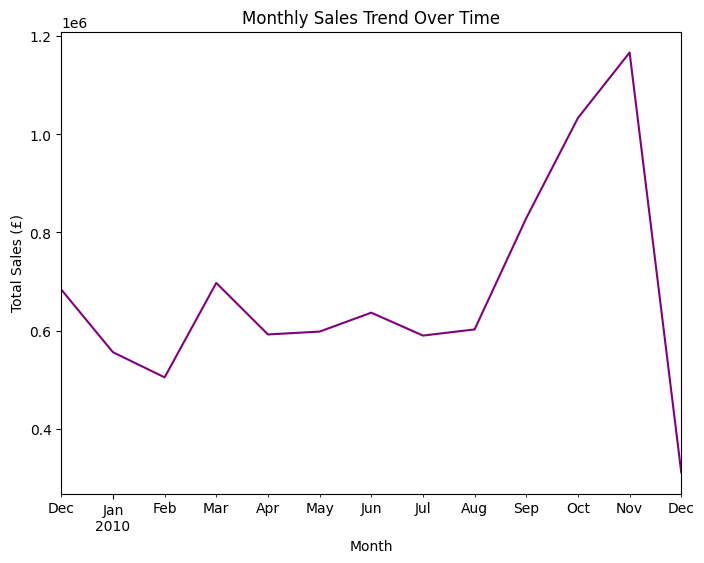

In [8]:
# Monthly Sales Trend
df["Month"] = df["InvoiceDate"].dt.to_period("M")
monthly_sales = df.groupby("Month")["TotalPrice"].sum()

plt.figure(figsize=(8, 6))
monthly_sales.plot(color="purple")
plt.title("Monthly Sales Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Total Sales (£)")
plt.show()

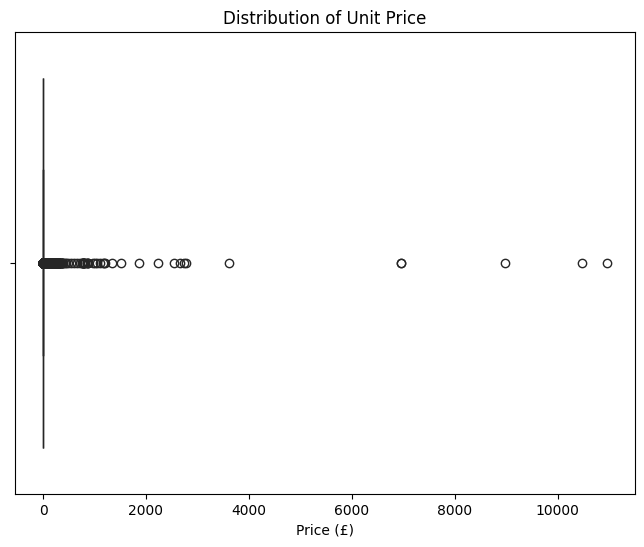

In [9]:
# Unit Price Distribution
plt.figure(figsize=(8, 6))
sns.boxplot(x=df["Price"], color="green")
plt.title("Distribution of Unit Price")
plt.xlabel("Price (£)")
plt.show()

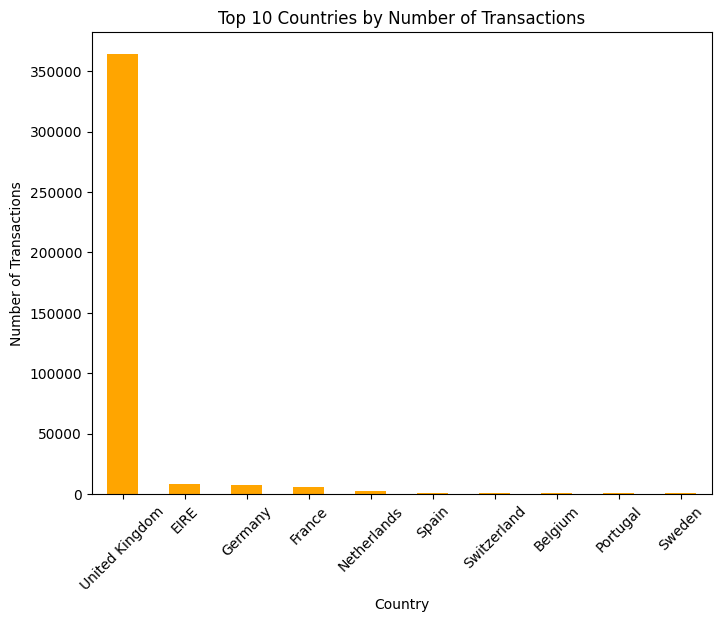

In [10]:
# Top 10 Countries by Number of Transactions
top_countries = df["Country"].value_counts().head(10)

plt.figure(figsize=(8, 6))
top_countries.plot(kind="bar", color="orange")
plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Country")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.show()

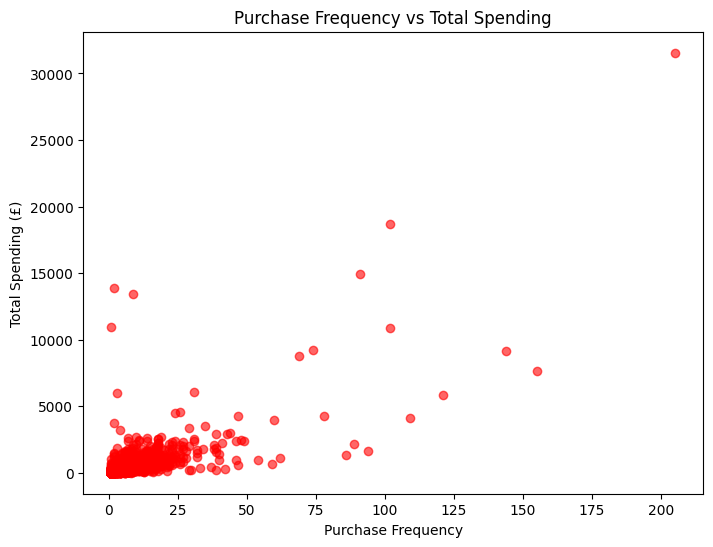

In [11]:
# Purchase Frequency vs Total Spending
plt.figure(figsize=(8, 6))
plt.scatter(
    customer_features["PurchaseFrequency"],
    customer_features["TotalSpending"],
    color="red",
    alpha=0.6
)
plt.title("Purchase Frequency vs Total Spending")
plt.xlabel("Purchase Frequency")
plt.ylabel("Total Spending (£)")
plt.show()